# Activity. Supervised Machine Learning
**Autor:** Gil Brandon Garcia Contreras
**Matricula:** A01254164
**Fecha:** 3 de marzo de 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Decission Tree
from sklearn import tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import plot_tree, DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler

# Random Forest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

# KNN
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# SVM
from sklearn.svm import SVC

## Import Dataset

In [49]:
col_names = ['date', 'precipitation',	'temp_max',	'temp_min',	'wind', 'weather'] 

df = pd.read_csv('../../seattle-weather(in).csv', names=col_names, header=None, skiprows=1)
df = df.drop('date', axis=1)

display(df.head())

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain


# Deccision Tree Classification Model
## Balancing

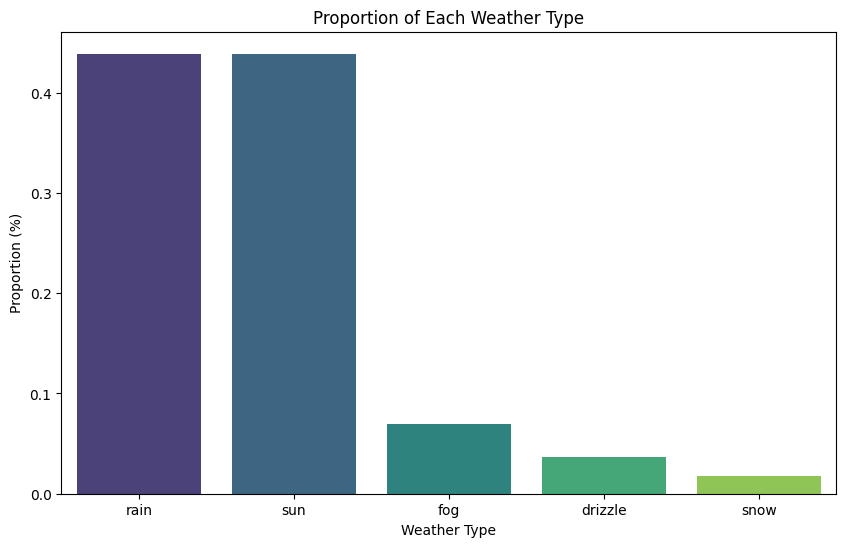

Counter({'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 'snow': 26})


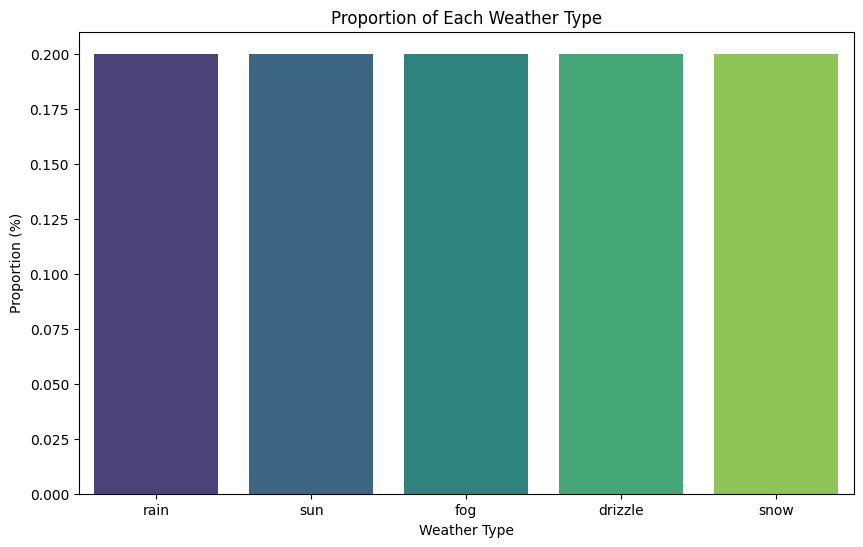

Counter({'rain': 449, 'sun': 449, 'fog': 449, 'drizzle': 449, 'snow': 449})


In [50]:
porcentajes = df['weather'].value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes.index, y=porcentajes.values, hue=porcentajes.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()

X = df.drop('weather', axis=1)
y = df['weather']

print(Counter(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

porcentajes_balanced = y_train_balanced.value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes_balanced.index, y=porcentajes_balanced.values, hue=porcentajes_balanced.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()
print(Counter(y_train_balanced))

## Model

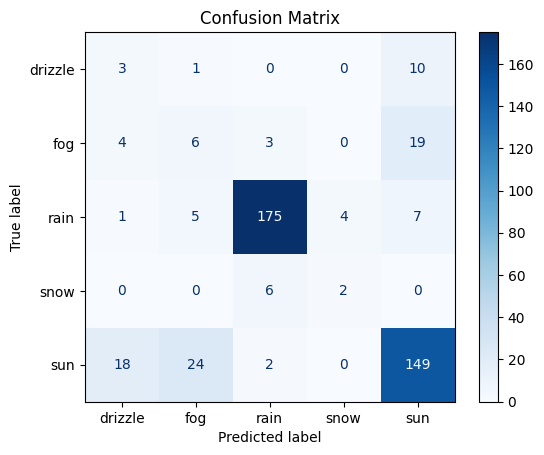

Classification Report:
                precision    recall  f1-score   support

     drizzle       0.12      0.21      0.15        14
         fog       0.17      0.19      0.18        32
        rain       0.94      0.91      0.93       192
        snow       0.33      0.25      0.29         8
         sun       0.81      0.77      0.79       193

    accuracy                           0.76       439
   macro avg       0.47      0.47      0.47       439
weighted avg       0.79      0.76      0.77       439



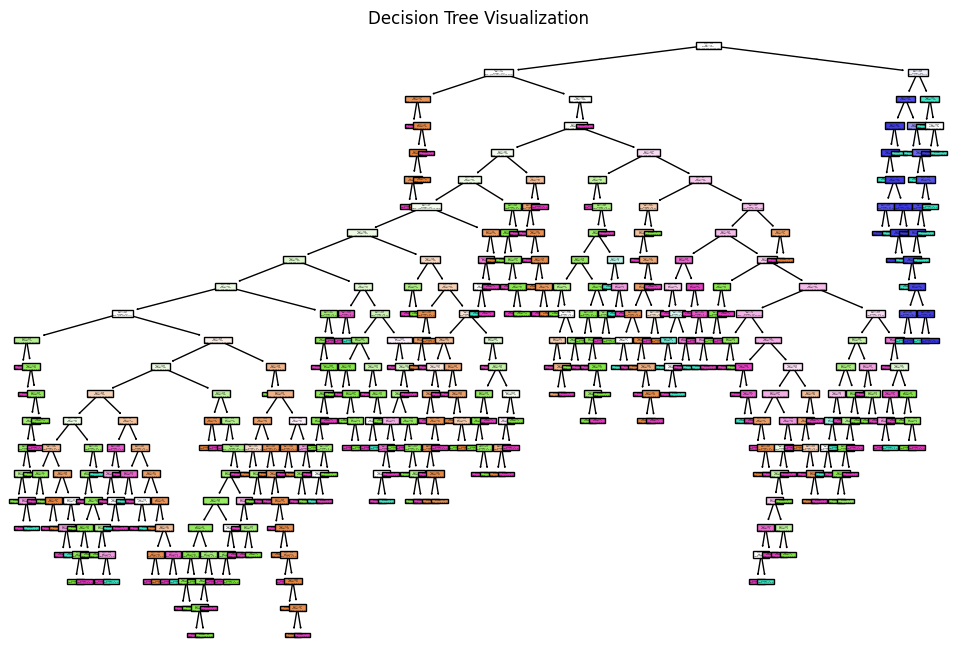

In [52]:
clf = DecisionTreeClassifier()
clf.fit(X_train_balanced, y_train_balanced)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


report = classification_report(y_test, y_pred, labels=clf.classes_)
print('Classification Report:\n ', report)

plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

## Hyperparameters

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparameters: {'max_depth': 4, 'max_features': 'log2', 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'min_samples_split': 4}


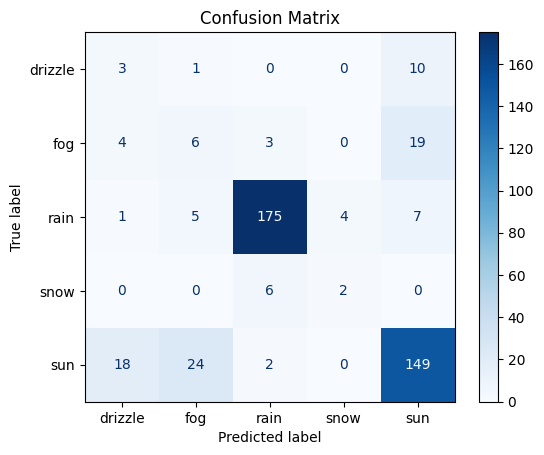

Classification Report:
                precision    recall  f1-score   support

     drizzle       0.12      0.21      0.15        14
         fog       0.17      0.19      0.18        32
        rain       0.94      0.91      0.93       192
        snow       0.33      0.25      0.29         8
         sun       0.81      0.77      0.79       193

    accuracy                           0.76       439
   macro avg       0.47      0.47      0.47       439
weighted avg       0.79      0.76      0.77       439



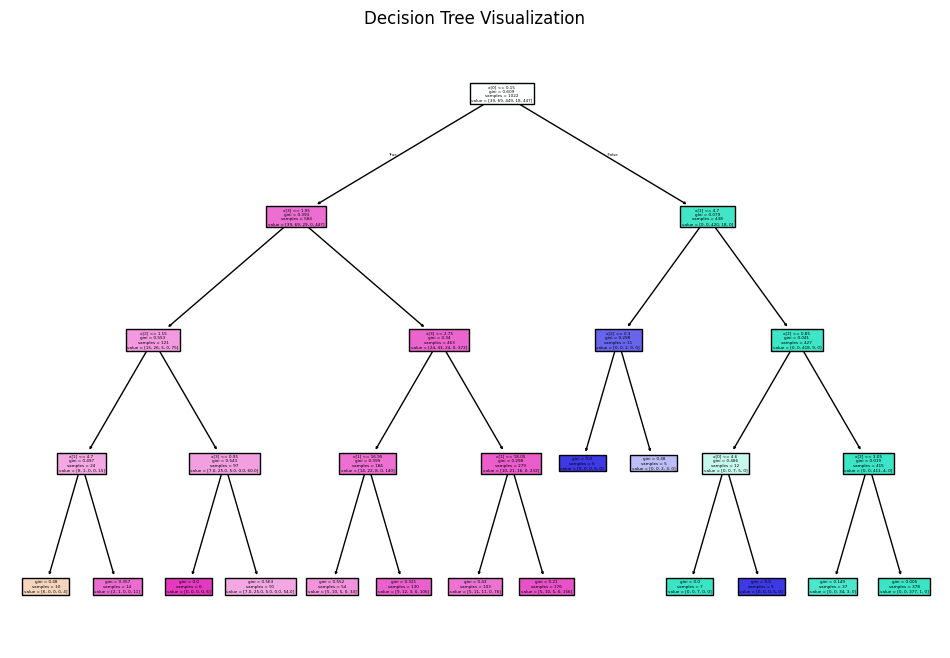

In [54]:
param_grid = {
    'max_depth' : [2, 3, 4, 5, None],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 5, 10, 20]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_test, y_pred, labels=best_model.classes_)
print('Classification Report:\n ', report)

plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

# Random Forest Classification Model
## Balance

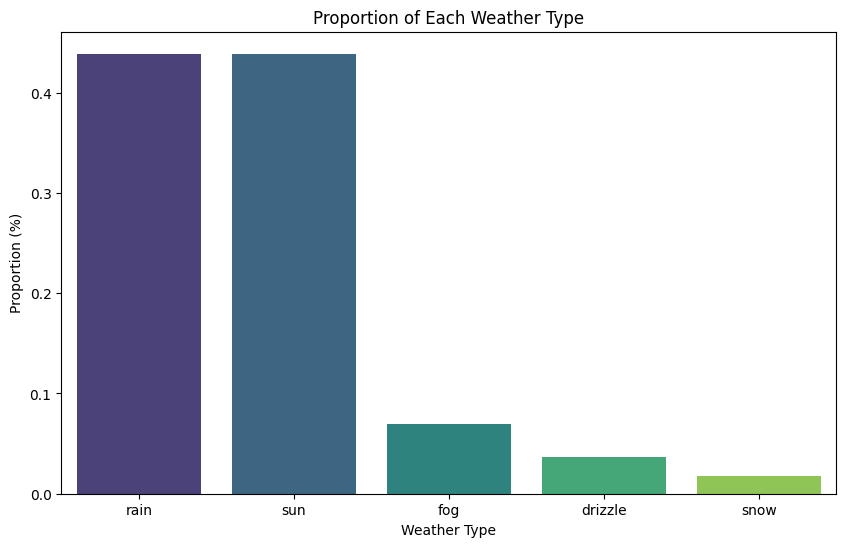

Counter({'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 'snow': 26})


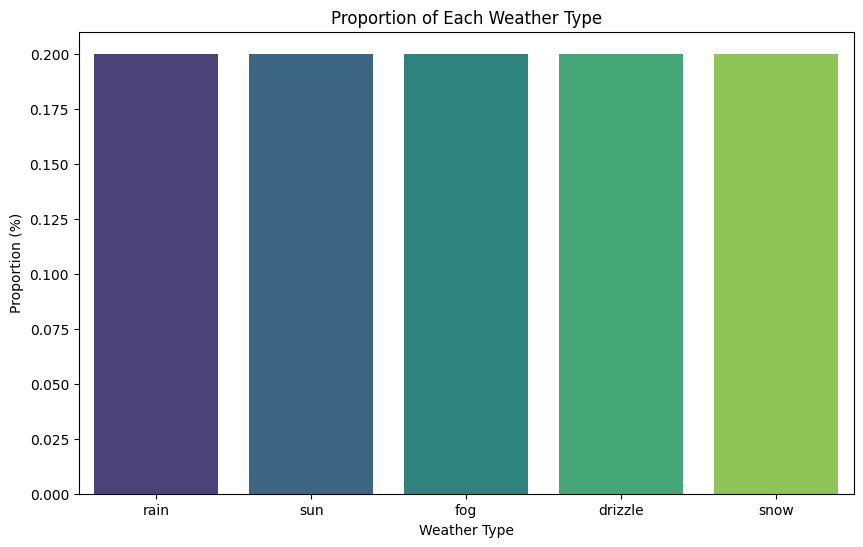

Counter({'rain': 449, 'sun': 449, 'fog': 449, 'drizzle': 449, 'snow': 449})


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

porcentajes = df['weather'].value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes.index, y=porcentajes.values, hue=porcentajes.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()

print(Counter(y))

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

porcentajes_balanced = y_train_balanced.value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes_balanced.index, y=porcentajes_balanced.values, hue=porcentajes_balanced.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()

print(Counter(Y_train_balanced))

## Accuracy for number of trees

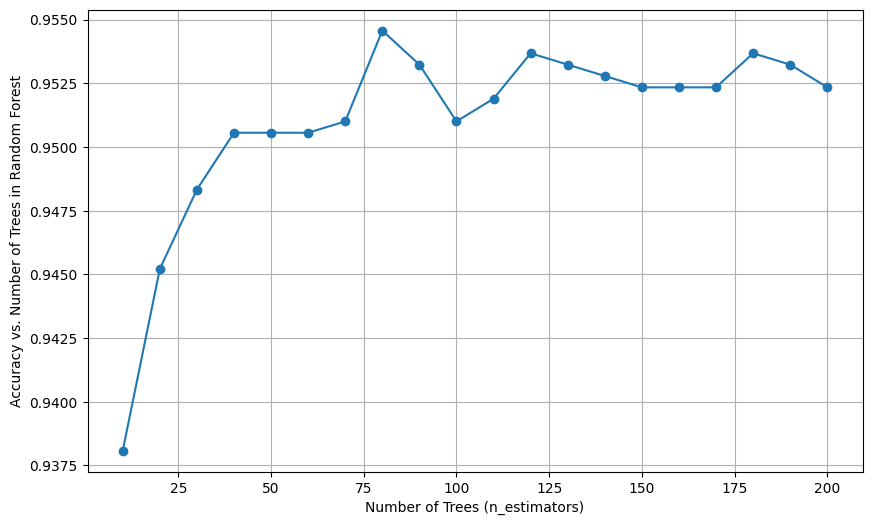

In [31]:
n_estimators_range = range(10, 201, 10)
cv_scores = []
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators = n, random_state = 42, n_jobs = -1)
    scores = cross_val_score(rf_temp, X_train_balanced, y_train_balanced, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, cv_scores, marker = 'o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy vs. Number of Trees in Random Forest")
plt.grid(True)
plt.show()

## Hyperparameters

In [55]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split' : [2, 4, 6], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

rf = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_) 

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 100}


## Model

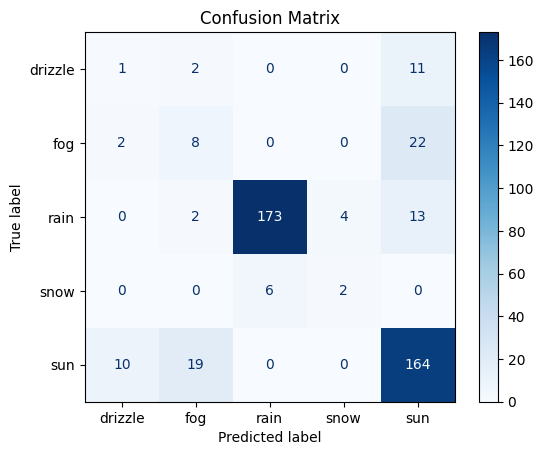

Classification Report: 
              precision    recall  f1-score   support

     drizzle       0.08      0.07      0.07        14
         fog       0.26      0.25      0.25        32
        rain       0.97      0.90      0.93       192
        snow       0.33      0.25      0.29         8
         sun       0.78      0.85      0.81       193

    accuracy                           0.79       439
   macro avg       0.48      0.46      0.47       439
weighted avg       0.79      0.79      0.79       439



<function matplotlib.pyplot.grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'>

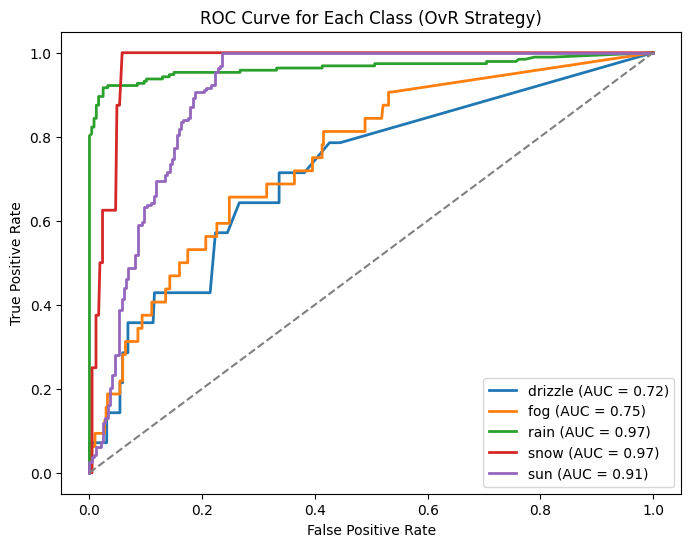

In [56]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report: ")
print(report)

y_test_binarized = label_binarize(y_test, classes = best_model.classes_)
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:,i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label],tpr[class_label], lw =2, 
             label = f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0,1], [0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc = "lower right")
plt.grid

# KNN

## Balance

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameters

In [51]:
knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15], 
    "weights": ["uniform", "distance"], 
    "p": [1, 2],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
}

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_
print("Best Hyperparameter:", grid_search.best_params_)

Fitting 5 folds for each of 112 candidates, totalling 560 fits
Best Hyperparameter: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}


C:\Users\gbgar\documents\TEC\FJ2026\TC2004B-gil-brandon\TC2004B_env\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.69963176 0.71919656 0.69865615 0.71724055 0.73585366 0.73779053
 0.72409374 0.73289813 0.75148733 0.74953611 0.72406504 0.73191296
 0.74756576 0.7505165  0.73679101 0.73875179 0.7514682  0.75931133
 0.7367671  0.74364419 0.74658058 0.7554089  0.73285509 0.7397274
 0.7504878  0.75637494 0.73285509 0.73877092 0.70061215 0.72017695
 0.69963654 0.71822095 0.73585366 0.73779053 0.72409374 0.73289813
 0.75148733 0.74953611 0.72406504 0.73191296 0.74756576 0.7505165
 0.73679101 0.73875179 0.7514682  0.75931133 0.7367671  0.74364419
 0.74658058 0.7554089  0.73285509 0.7397274  0.7504878  0.75637494
 0.73285509 0.73877092 0.69963176 0.71919656 0.69865615 0.71724055
 0.73585366 0.73779053 0.72409374 0.73289813 0.75148733 0.74953611
 0.72406504 0.73191296 0.74756576 0.7505165  0.73679101 0.73875179
 0.7514682 

## Model


Classification Report (Test):
              precision    recall  f1-score   support

     drizzle       0.33      0.07      0.12        14
         fog       0.14      0.03      0.05        32
        rain       0.88      0.84      0.86       192
        snow       1.00      0.12      0.22         8
         sun       0.69      0.88      0.77       193

    accuracy                           0.76       439
   macro avg       0.61      0.39      0.40       439
weighted avg       0.73      0.76      0.73       439



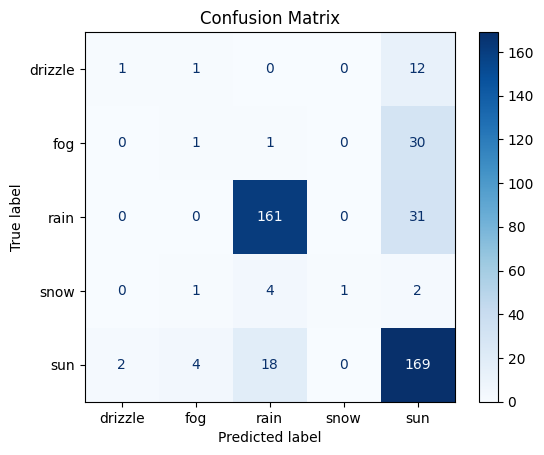

In [52]:
y_pred = best_model.predict(X_test_scaled)

print('\nClassification Report (Test):')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# SVM

## Import Dataset

In [2]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
col_names = ['sepal.length', 'sepal.width',	'petal.length',	'petal.width',	'variety'] 

df = pd.read_csv(url, names=col_names, header=None, skiprows=1)

display(df.head())

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Hyperparameters

In [4]:
X = df.drop('variety', axis=1)
y = df['variety']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

vm = SVC(probability=True, random_state=42)
param_grid = {
    'C' : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'degree' : [2, 3, 4],
    'gamma' : ['scale', 'auto']
}

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print('Best Hyperparamter:', grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparamter: {'C': 1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


## Model

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
  Versicolor       1.00      0.92      0.96        13
   Virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



<function matplotlib.pyplot.show(close=None, block=None)>

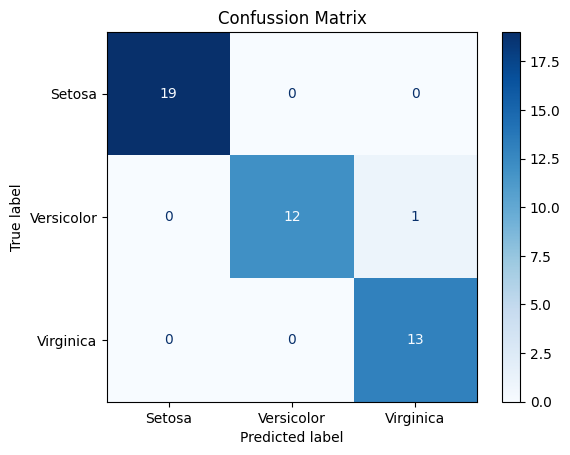

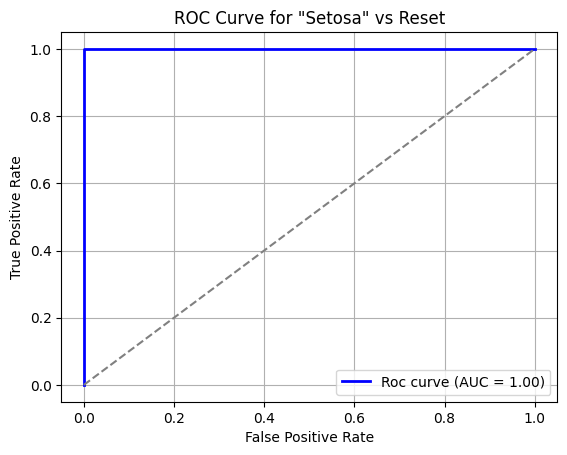

In [5]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confussion Matrix')
plt.show
report = classification_report(y_test, y_pred, labels=best_model.classes_)
print(report)

positive_class = 'Setosa'
y_test_binary = (y_test == positive_class).astype(int)
y_score = best_model.predict_proba(X_test)[:, list(best_model.classes_).index(positive_class)]

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Roc curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for "{positive_class}" vs Reset')
plt.legend(loc="lower right")
plt.grid(True)
plt.show